# 予測と正解の比較可視化ノートブック

## 目的
学習したMM-Grouding DINOで，指定した画像を推論し，予測と正解アノテーションを1枚に重ねて描画する．
学習ができているかを目視で確認するためのもの．

## 仕組み
- ノートブック内でモデルを読み込んで推論する（`DetInferencer` を使用）
- 対象画像は、ファイル名のリストで指定する
- 各画像について、予測と正解を重ねた比較画像を作成・保存する

## 使い方
1. **セル1（設定）** で、config・チェックポイント・対象画像リストなどを指定
2. **セル2〜4** で準備（モデル読み込み、関数定義）
3. **セル5（実行）** で比較画像を作成
4. 出力ディレクトリに保存された画像を確認する

## セル1：設定

In [28]:
# === config と チェックポイント ===
CONFIG = 'configs/mm_grounding_dino/grounding_dino_swin-t_finetune_8xb4_20e_underwater.py'
CHECKPOINT = 'underwater_work_dir/best_coco_bbox_mAP_epoch_20.pth'  # 最新のbestに合わせて変更する

# === データのルート（画像とアノテーションがある場所）===
DATA_ROOT = '/workspace/kouyou/datasets/rf100_domain/underwater'
SUBSET = 'valid'  # train または valid
ANN_FILE = f'{DATA_ROOT}/{SUBSET}/_annotations.coco.json'
IMG_DIR = f'{DATA_ROOT}/{SUBSET}'

# === 対象画像（ファイル名のリストで指定）===
# Underwater ドメイン
TARGET_IMAGES = [
    'IMG_0964_JPG_jpg.rf.c345c64f5ab4eb4948f1cc128fcf9fa4.jpg',
    'u001151_jpg.rf.b3dcb52fe5c953293da89f7b3e805d10.jpg',
    'c000001_jpg.rf.b04f88028bf0e69d8367eb70213e8a60.jpg',
    'c000004_jpg.rf.8c546b6574c602845ba4a6807b0e2336.jpg',
]

# === 推論の設定 ===
SCORE_THR = 0.3      # このスコア以上の予測だけを描画する
DEVICE = 'cuda:0'
CHUNKED_SIZE = -1    # カテゴリが非常に多い場合に使う（-1で無効）

# === 出力先 ===
OUT_DIR = 'compare_vis_output'

print('設定を読み込みました。')
print(f'  config: {CONFIG}')
print(f'  checkpoint: {CHECKPOINT}')
print(f'  対象画像: {len(TARGET_IMAGES)}枚')
print(f'  スコアしきい値: {SCORE_THR}')
print(f'  出力先: {OUT_DIR}')

設定を読み込みました。
  config: configs/mm_grounding_dino/grounding_dino_swin-t_finetune_8xb4_20e_underwater.py
  checkpoint: underwater_work_dir/best_coco_bbox_mAP_epoch_20.pth
  対象画像: 4枚
  スコアしきい値: 0.3
  出力先: compare_vis_output


## セル2：クラス名リストの取得とテキストプロンプト作成
アノテーションファイルから，クラス名（id順）を取得し，Grouding DINO用のテキストプロンプトを作成する．

In [29]:
import os
import json

# アノテーションを読み込む
with open(ANN_FILE) as f:
    coco = json.load(f)

# クラス名（id順）
categories_sorted = sorted(coco['categories'], key=lambda x: x['id'])
class_names = [c['name'] for c in categories_sorted]
# クラスID → クラス名
catid_to_name = {c['id']: c['name'] for c in coco['categories']}

# Grounding DINO 用テキストプロンプト（ピリオド区切り）
texts_prompt = ' . '.join(class_names) + ' .'

print(f'クラス数: {len(class_names)}')
print(f'テキストプロンプト:')
print(texts_prompt)

# image_id <-> file_name の対応、各画像のアノテーションをまとめておく
fname_to_imgid = {img['file_name']: img['id'] for img in coco['images']}
from collections import defaultdict
imgid_to_anns = defaultdict(list)
for a in coco['annotations']:
    imgid_to_anns[a['image_id']].append(a)

クラス数: 28
テキストプロンプト:
pipe . fish . jellyfish . penguin . puffin . shark . starfish . stingray . peix . taca . echinus . holothurian . scallop . waterweeds . Arborescent . Caespitose-a . Caespitose-b . Columnar . Corymbose . Digitate . Encrusting . Foliose . Massive-Faviidae . Massive-Merulinidae . Massive-Mussidae . Massive-Poritidae . Solitary . Tabular .


## セル3：モデルの読み込み
推論用モデルを読み込む．

In [30]:
from mmdet.apis import DetInferencer

# 推論器を初期化
inferencer = DetInferencer(
    model=CONFIG,
    weights=CHECKPOINT,
    device=DEVICE,
    palette='none',
)
# chunked_size を設定（カテゴリ数が多い場合の対策。-1で無効）
inferencer.model.test_cfg.chunked_size = CHUNKED_SIZE

print('モデルを読み込みました。')

Loads checkpoint by local backend from path: underwater_work_dir/best_coco_bbox_mAP_epoch_20.pth
モデルを読み込みました。


## セル4：推論と比較描画用の関数
1枚の画像について，推論し予測と正解の重ねて描画する．

In [31]:
from PIL import Image, ImageDraw, ImageFont


def load_font(size):
    try:
        return ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf', size)
    except Exception:
        return ImageFont.load_default()


FONT = load_font(12)


def infer_one(img_path):
    """1枚の画像を推論し、labels/scores/bboxes(x1y1x2y2) を返す。"""
    result = inferencer(
        inputs=img_path,
        texts=texts_prompt,
        custom_entities=True,
        pred_score_thr=SCORE_THR,   # 可視化用のしきい値（戻り値には全予測が入る場合あり）
        return_datasamples=False,
        no_save_vis=True,
        no_save_pred=True,
        return_vis=False,
    )
    pred = result['predictions'][0]
    return pred['labels'], pred['scores'], pred['bboxes']


def draw_compare(img_path, fname, save_path):
    """予測（赤）と正解（緑）を重ねて描画し、保存する。"""
    base = Image.open(img_path).convert('RGB')
    draw = ImageDraw.Draw(base)

    # --- 正解（緑）を描画 ---
    img_id = fname_to_imgid.get(fname)
    gt_anns = imgid_to_anns.get(img_id, [])
    for a in gt_anns:
        x, y, w, h = a['bbox']  # COCO形式 x,y,w,h
        draw.rectangle([x, y, x + w, y + h], outline=(0, 255, 0), width=3)
        label = f"GT:{catid_to_name[a['category_id']]}"
        tb = draw.textbbox((0, 0), label, font=FONT)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]
        draw.rectangle([x, y - th - 3, x + tw + 4, y], fill=(0, 150, 0))
        draw.text((x + 2, y - th - 3), label, fill=(255, 255, 255), font=FONT)

    # --- 予測（赤）を描画（スコアしきい値以上のみ）---
    labels, scores, bboxes = infer_one(img_path)
    n_pred = 0
    for label_id, score, bbox in zip(labels, scores, bboxes):
        if score < SCORE_THR:
            continue
        n_pred += 1
        x1, y1, x2, y2 = bbox  # x1,y1,x2,y2
        draw.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=2)
        name = class_names[label_id] if label_id < len(class_names) else f'id{label_id}'
        label = f"{name}:{score:.2f}"
        tb = draw.textbbox((0, 0), label, font=FONT)
        tw, th = tb[2] - tb[0], tb[3] - tb[1]
        draw.rectangle([x2 - tw - 4, y2, x2, y2 + th + 3], fill=(200, 0, 0))
        draw.text((x2 - tw - 2, y2), label, fill=(255, 255, 255), font=FONT)

    base.save(save_path)
    return len(gt_anns), n_pred


print('関数を定義しました。')

関数を定義しました。


## セル5：実行
対象画像全てについて，比較画像を作成・保存する．

In [32]:
os.makedirs(OUT_DIR, exist_ok=True)

print(f'比較画像を作成します（緑=正解, 赤=予測, スコア>={SCORE_THR}）')
print('=' * 70)

for fname in TARGET_IMAGES:
    img_path = os.path.join(IMG_DIR, fname)
    if not os.path.exists(img_path):
        print(f'  画像が見つかりません: {fname}')
        continue
    save_path = os.path.join(OUT_DIR, 'compare_' + fname.split('.rf.')[0] + '.png')
    n_gt, n_pred = draw_compare(img_path, fname, save_path)
    print(f'  {fname[:40]}...')
    print(f'    正解: {n_gt}個, 予測(スコア>={SCORE_THR}): {n_pred}個 -> {save_path}')

print('=' * 70)
print(f'完了。{OUT_DIR} に比較画像を保存しました。')

比較画像を作成します（緑=正解, 赤=予測, スコア>=0.3）


  IMG_0964_JPG_jpg.rf.c345c64f5ab4eb4948f1...
    正解: 8個, 予測(スコア>=0.3): 8個 -> compare_vis_output/compare_IMG_0964_JPG_jpg.png


  u001151_jpg.rf.b3dcb52fe5c953293da89f7b3...
    正解: 57個, 予測(スコア>=0.3): 64個 -> compare_vis_output/compare_u001151_jpg.png


  c000001_jpg.rf.b04f88028bf0e69d8367eb702...
    正解: 6個, 予測(スコア>=0.3): 7個 -> compare_vis_output/compare_c000001_jpg.png


  c000004_jpg.rf.8c546b6574c602845ba4a6807...
    正解: 1個, 予測(スコア>=0.3): 2個 -> compare_vis_output/compare_c000004_jpg.png
完了。compare_vis_output に比較画像を保存しました。


## セル6：ノートブック内で画像を表示する
作成した比較画像をノートブック内に表示して認識する．

compare_vis_output/compare_IMG_0964_JPG_jpg.png


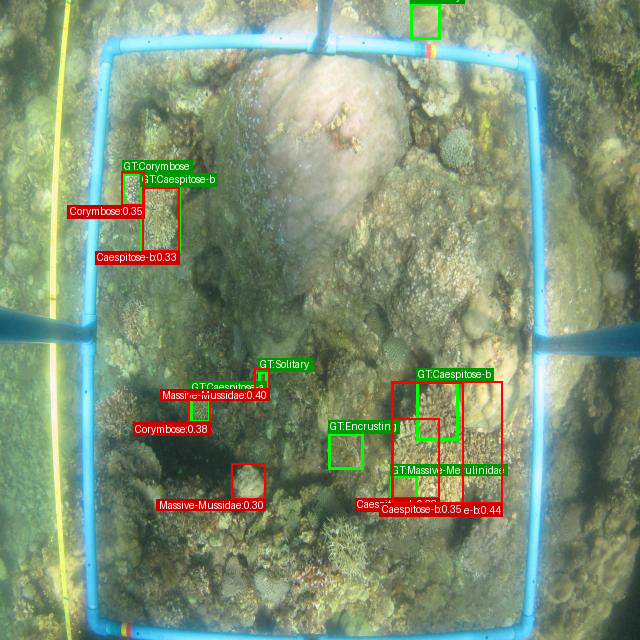

compare_vis_output/compare_c000001_jpg.png


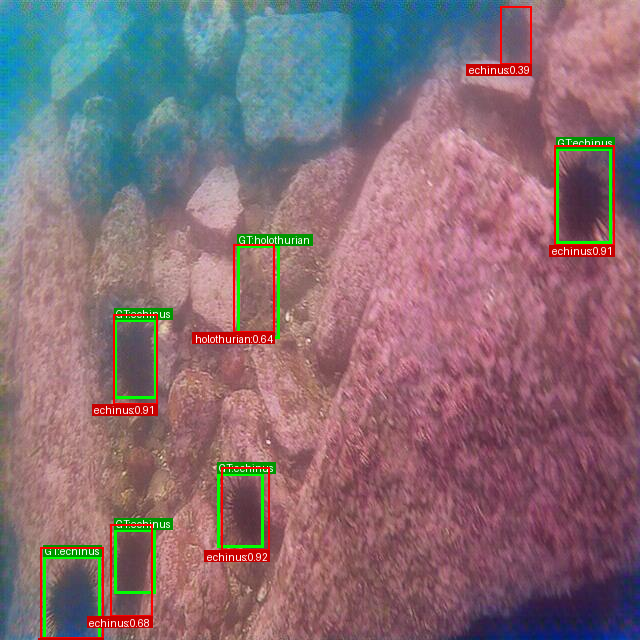

compare_vis_output/compare_c000004_jpg.png


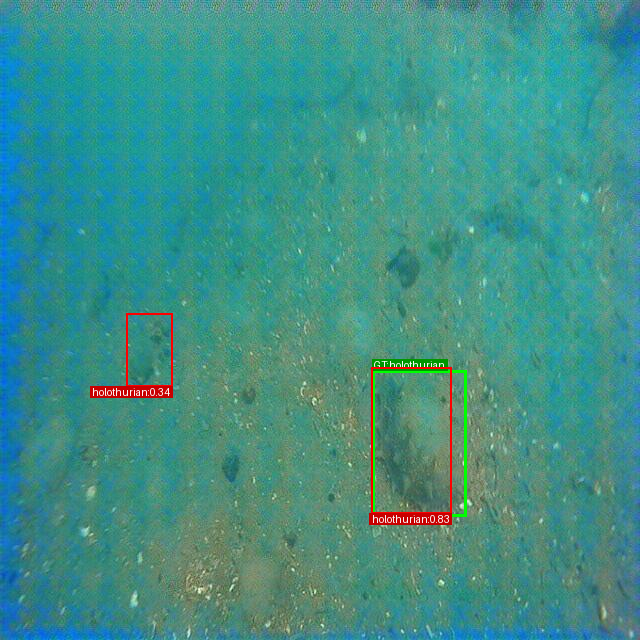

compare_vis_output/compare_u001151_jpg.png


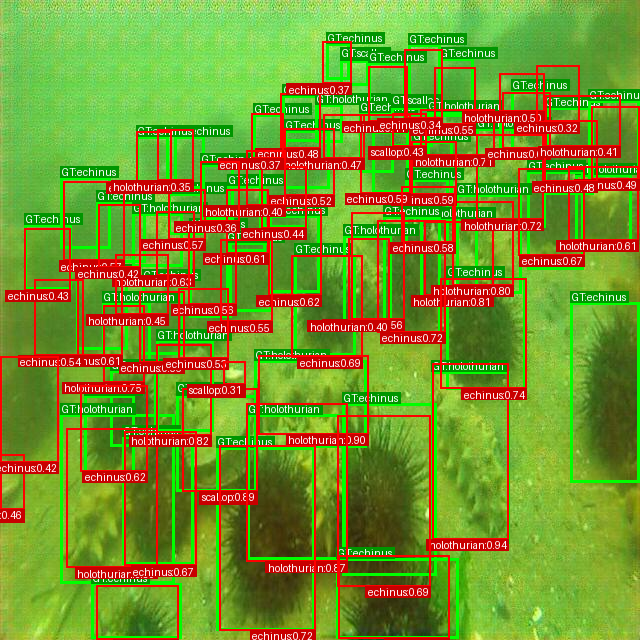

In [33]:
from IPython.display import Image as IPImage, display
import glob

for path in sorted(glob.glob(os.path.join(OUT_DIR, '*.png'))):
    print(path)
    display(IPImage(filename=path))